In [ ]:
import torch
import torch.nn as nn
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image, ImageEnhance, ImageFilter #image enhance and filter just for the synthetic noising

import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import random

import cv2 # for synthetically noising

import skimage
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from matplotlib import pyplot as plt #for visualizing 

Matplotlib is building the font cache; this may take a moment.


# Preexisting Image Restoration Practices

#### skimage, etc

# Denoising Dataset class

In [74]:
class DenoisingPairedDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.split = split.lower()
        
        self.images_dir = os.path.join(root_dir, split, 'images')
        self.noisy_images_dir = os.path.join(root_dir, split, 'noisy_images')

        if not os.path.exists(self.images_dir) or not os.path.exists(self.noisy_images_dir):
            raise ValueError(f"Missing images or noisy_images directories in the path: {root_dir}/{split}")

        self.filenames = [f for f in os.listdir(self.images_dir) if os.path.exists(os.path.join(self.noisy_images_dir, f))]

        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        file_name = self.filenames[idx]
        noisy_path = os.path.join(self.noisy_images_dir, file_name)
        clean_path = os.path.join(self.images_dir, file_name)

        noisy_image = Image.open(noisy_path).convert("RGB")
        clean_image = Image.open(clean_path).convert("RGB")

        if self.transform:
            noisy_image = self.transform(noisy_image)
            clean_image = self.transform(clean_image)

        return noisy_image, clean_image #, file_name #return the file name (not sure why you would but just in case)
        

# Root directories

In [75]:
root_dir = '/Users/vivekasaraiya/Downloads/cs230_VIVEKA_temp/aquarium_pretrain/'
splits = ['train', 'test','valid']

# Synthetically Noising Aquarium Data

## Sub functions:

In [ ]:
def add_color_cast(np_image):
    '''Uses a numpy rendition of an image to apply underwater color cast'''
    blue_tint = random.uniform(0.9, 1.2)
    green_tint = random.uniform(0.9, 1.2)
    red_tint = random.uniform(0.6, 1.0)
    np_image[:, :, 0] *= blue_tint  
    np_image[:, :, 1] *= green_tint 
    np_image[:, :, 2] *= red_tint
    return np.clip(np_image, 0, 255)

In [ ]:
def add_gaussian_blur(image):
    blur_radius = random.uniform(0.5, 2)
    return image.filter(ImageFilter.GaussianBlur(radius=blur_radius))

In [ ]:
def add_gaussian_noise(np_image):
    noise_std = random.uniform(5, 20)
    noise = np.random.normal(0, noise_std, np_image.shape).astype(np.float32)
    return np.clip(np_image + noise, 0, 255)

In [ ]:
def adjust_brightness(image):
    brightness_factor = random.uniform(0.8, 1.2)
    enhancer = ImageEnhance.Brightness(image)
    return enhancer.enhance(brightness_factor)

In [35]:
def add_speckles(np_image):
    """Adds translucent elliptical speckles with random distribution."""
    speckle_mask = np.zeros_like(np_image, dtype=np.float32)
    speckle_mask = cv2.GaussianBlur(speckle_mask, (3, 3), sigmaX=1)

    speckle_density = random.randint(50, 150)
    distribution_type = random.choice(["uniform", "concentrated"])
    random_center_x = random.randint(np_image.shape[1] // 4, 3 * np_image.shape[1] // 4)
    random_center_y = random.randint(np_image.shape[0] // 4, 3 * np_image.shape[0] // 4)

    for _ in range(speckle_density):
        if distribution_type == "uniform":
            x = random.randint(0, np_image.shape[1] - 1)
            y = random.randint(0, np_image.shape[0] - 1)
        else:  # Concentrated
            spread_x = random.randint(50, 100)
            spread_y = random.randint(50, 100)
            x = random.randint(random_center_x - spread_x, random_center_x + spread_x)
            y = random.randint(random_center_y - spread_y, random_center_y + spread_y)
            x = np.clip(x, 0, np_image.shape[1] - 1)
            y = np.clip(y, 0, np_image.shape[0] - 1)

        size_x = random.randint(1, 5)
        size_y = random.randint(1, 5) # this would be used if we want the speckles to be elliptical
        intensity = random.uniform(25, 100)

        for i in range(-size_y, size_y):
            for j in range(-size_x, size_x):
                if ((j / size_x)**2 + (i / size_y)**2) <= 1:
                    if 0 <= y + i < np_image.shape[0] and 0 <= x + j < np_image.shape[1]:
                        speckle_mask[y + i, x + j] += intensity

    return np.clip(np_image + speckle_mask, 0, 255)

In [36]:
def apply_motion_blur(image, kernel_size=30, angle=0):
    """
    Applies motion blur to the input image in any direction.

    Parameters:
    - image (PIL.Image or NumPy array): The input image.
    - kernel_size (int): The size of the motion blur kernel. Higher values create stronger blur.
    - angle (float): The angle of the motion blur in degrees (0 = horizontal, 90 = vertical).

    Returns:
    - NumPy array: The motion-blurred image.
    """
    # Convert to NumPy array if the input is a PIL Image
    if isinstance(image, Image.Image):
        np_image = np.array(image)
    else:
        np_image = image

    # Create an initial horizontal kernel
    kernel = np.zeros((kernel_size, kernel_size))
    kernel[kernel_size // 2, :] = np.ones(kernel_size)  # Horizontal line

    # Normalize the kernel
    kernel /= kernel_size

    # Rotate the kernel to the specified angle
    rotation_matrix = cv2.getRotationMatrix2D((kernel_size // 2, kernel_size // 2), angle, 1)
    rotated_kernel = cv2.warpAffine(kernel, rotation_matrix, (kernel_size, kernel_size))

    # Apply the rotated kernel
    blurred_image = cv2.filter2D(np_image, -1, rotated_kernel)

    return blurred_image

In [37]:
noising_functions_list = ['add_color_cast', 'add_gaussian_blur', 'add_gaussian_noise', 'adjust_brightness', 'add_speckles', 'apply_motion_blur']

### Encompassing function to add random underwater effects

In [38]:
def apply_random_underwater_effects(image):
    np_image = np.array(image).astype(np.float32)

    if random.random() < 0.9:
        np_image = add_color_cast(np_image)

    if random.random() < 0.8:
        np_image = add_gaussian_noise(np_image)

    if random.random() < 0.7:
        np_image = add_speckles(np_image)

    image = Image.fromarray(np_image.astype(np.uint8))

    if random.random() < 0.8:
        image = add_gaussian_blur(image)

    if random.random() < 0.7:
        image = adjust_brightness(image)

    if random.random() < 0.5:
        image = apply_motion_blur(image, angle=random.random() * 90)
    
    #print(np_image)
    #print(image)
    #print(np_image.dtype)
    
    return image

## Create noised images for all directories under root_dir

In [ ]:
# root_dir = '/path/to/your/directory'

# splits = ['train', 'test', 'valid']

In [46]:
#RUN THIS CELL ONCE ONLY TO CREATE NOISY IMAGES. COMMENT OUT WHEN DONE. 
max_test_images = 10

for split in splits:
    images_dir = os.path.join(root_dir, split, 'images')
    noisy_images_dir = os.path.join(root_dir, split, 'noisy_images')

    if not os.path.exists(noisy_images_dir):
        os.makedirs(noisy_images_dir)

    processed_count = 0

    for file_name in os.listdir(images_dir):
        if file_name.endswith('.jpg') or file_name.endswith('.png'):
            image_path = os.path.join(images_dir, file_name)
            image = Image.open(image_path).convert("RGB")

            noisy_image = apply_random_underwater_effects(image)
            if isinstance(noisy_image, np.ndarray):
                noisy_image = Image.fromarray(noisy_image)

            noisy_image.save(os.path.join(noisy_images_dir, file_name))

            ''' Uncomment this section to test on a smaller batch of images '''
            # processed_count += 1
            # if processed_count >= max_test_images:
            #     break
            
    print(f"Noisy images created for {split} images")


Noisy images created for train images
Noisy images created for test images
Noisy images created for valid images


# Denoising Model Class

### Architecture 1: basic model.
consider adding: dropout, batch normalization layers.

In [40]:
class DenoisingCNN(nn.Module):
    def __init__(self):
        super(DenoisingCNN, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()  # To ensure pixel values are in [0, 1]
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# Denoising Trainer class

In [101]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np

class Trainer:
    def __init__(self, model, device, criterion, optimizer, save_path='best_model.pth'):
        self.model = model
        self.device = device
        self.criterion = criterion
        self.optimizer = optimizer
        self.save_path = save_path

        self.train_losses = []
        self.val_losses = []
        self.best_val_loss = float('inf')

    def train(self, train_loader, valid_loader, num_epochs=10):
        for epoch in range(num_epochs):
            self.model.train()
            running_train_loss = 0.0
            total_train_samples = 0

            for noisy_images, clean_images in train_loader:
                noisy_images = noisy_images.to(self.device)
                clean_images = clean_images.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(noisy_images)
                loss = self.criterion(outputs, clean_images)
                loss.backward()
                self.optimizer.step()

                running_train_loss += loss.item() * noisy_images.size(0)
                total_train_samples += noisy_images.size(0)

            epoch_train_loss = running_train_loss / total_train_samples
            self.train_losses.append(epoch_train_loss)
            print(f'Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_train_loss:.4f}')

            self.model.eval()
            running_val_loss = 0.0
            total_val_samples = 0

            with torch.no_grad():
                for noisy_images, clean_images in valid_loader:
                    noisy_images = noisy_images.to(self.device)
                    clean_images = clean_images.to(self.device)

                    outputs = self.model(noisy_images)
                    loss = self.criterion(outputs, clean_images)

                    running_val_loss += loss.item() * noisy_images.size(0)
                    total_val_samples += noisy_images.size(0)

            epoch_val_loss = running_val_loss / total_val_samples
            self.val_losses.append(epoch_val_loss)
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {epoch_val_loss:.4f}')

            if epoch_val_loss < self.best_val_loss:
                self.best_val_loss = epoch_val_loss
                torch.save(self.model.state_dict(), self.save_path)
                print(f"Model saved with validation loss: {epoch_val_loss:.4f}")

    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        total_samples = 0
        total_psnr = 0.0
        total_ssim = 0.0

        with torch.no_grad():
            for noisy_images, clean_images in data_loader:
                noisy_images = noisy_images.to(self.device)
                clean_images = clean_images.to(self.device)

                outputs = self.model(noisy_images)
                loss = self.criterion(outputs, clean_images)

                running_loss += loss.item() * noisy_images.size(0)
                total_samples += noisy_images.size(0)

                # NEW METRICS pSNR, SSIM ADDED HERE
                outputs_np = outputs.cpu().numpy().transpose(0, 2, 3, 1)
                clean_images_np = clean_images.cpu().numpy().transpose(0, 2, 3, 1)
                for o, c in zip(outputs_np, clean_images_np):
                    total_psnr += psnr(c, o, data_range=1.0)
                    total_ssim += ssim(c, o, data_range=1.0, win_size=3, channel_axis=-1)

        avg_loss = running_loss / total_samples
        avg_psnr = total_psnr / total_samples
        avg_ssim = total_ssim / total_samples

        print(f"Avg Loss: {avg_loss:.4f}, Avg PSNR: {avg_psnr:.4f}, Avg SSIM: {avg_ssim:.4f}")
        return avg_loss, avg_psnr, avg_ssim


# Make dataset, train loaders, val loaders

##### main model creation pipeline

In [ ]:
hyperparams = ['batch_size', 'lr', 'num_epochs', 'dropout_rate']

In [76]:
#Transforms
normalization_mean = normalization_std = [0.5, 0.5, 0.5]

transform_normalize = T.Compose([T.Resize((224, 224)),  #resize
                        T.ToTensor(),                   # to tensor
                        T.Normalize(mean=normalization_mean, std=normalization_std)]) #normalize

transform_regular = T.ToTensor()

transform_resize = T.Compose( [ T.Resize((224,224)) , T.ToTensor() ] ) #IMPORTANT: size is taken from datasets.py transform in order to match 

create dataset

In [91]:
train_data = DenoisingPairedDataset(root_dir=root_dir, split='train', transform=transform_normalize)
valid_data = DenoisingPairedDataset(root_dir=root_dir, split='valid', transform=transform_normalize)
test_data = DenoisingPairedDataset(root_dir=root_dir, split='test', transform=transform_normalize)

create DataLoaders

In [92]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

create Model, device

In [99]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = DenoisingCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

trainer = Trainer(model, device, criterion, optimizer, save_path="best_denoising_model.pth")

Using device: cpu


In [95]:
num_epochs = 2

trainer.train(train_loader, valid_loader, num_epochs=num_epochs)

Epoch 1/2, Training Loss: 0.6904
Epoch 1/2, Validation Loss: 0.3172
Model saved with validation loss: 0.3172
Epoch 2/2, Training Loss: 0.2949
Epoch 2/2, Validation Loss: 0.2866
Model saved with validation loss: 0.2866


In [100]:
val_loss, val_psnr, val_ssim = trainer.evaluate(valid_loader)
print(f"Validation - Loss: {val_loss:.4f}, PSNR: {val_psnr:.4f}, SSIM: {val_ssim:.4f}")

test_loss, test_psnr, test_ssim = trainer.evaluate(test_loader)
print(f"Test - Loss: {test_loss:.4f}, PSNR: {test_psnr:.4f}, SSIM: {test_ssim:.4f}")


Avg Loss: 0.8224, Avg PSNR: 1.1203, Avg SSIM: -0.2608
Validation - Loss: 0.8224, PSNR: 1.1203, SSIM: -0.2608
Avg Loss: 0.8693, Avg PSNR: 0.8418, Avg SSIM: -0.2822
Test - Loss: 0.8693, PSNR: 0.8418, SSIM: -0.2822


##### visualize dataset real quick tehe -> this can go in the notebook that will be created in the synthetic noising in the VM (this is not important to have open rn)

In [102]:
dataset = train_data
noisy, clean = dataset[248]


In [103]:
dataset[0][0].shape

torch.Size([3, 224, 224])

In [104]:
def unnormalize(img_tensor, mean, std):
    """
    Unnormalize a tensor image for visualization purposes.
    """
    img_tensor = img_tensor.clone().detach().cpu()  # Clone and move to CPU
    for t, m, s in zip(img_tensor, mean, std):
        t.mul_(s).add_(m)  # Unnormalize
    return img_tensor

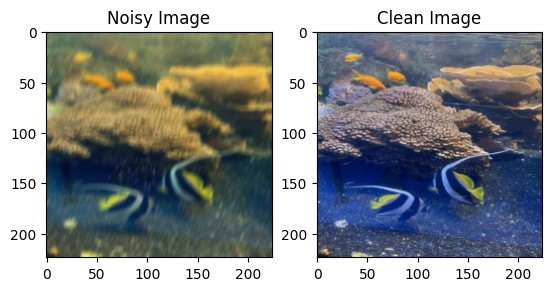

In [105]:
noisy_unnormalized = unnormalize(noisy, normalization_mean, normalization_std)
clean_unnormalized = unnormalize(clean, normalization_mean, normalization_std)

# Plot the images
plt.subplot(1, 2, 1)
plt.imshow(noisy_unnormalized.permute(1, 2, 0).clip(0, 1))  # Clip to [0, 1] for visualization
plt.title("Noisy Image")
plt.subplot(1, 2, 2)
plt.imshow(clean_unnormalized.permute(1, 2, 0).clip(0, 1))  # Clip to [0, 1] for visualization
plt.title("Clean Image")
plt.show()

In [89]:
# plt.subplot(1, 2, 1)
# plt.imshow(noisy.permute(1, 2, 0))
# plt.title("Noisy Image")
# plt.subplot(1, 2, 2)
# plt.imshow(clean.permute(1, 2, 0))
# plt.title("Clean Image")
# plt.show()